**Forcing Extremes**  
**Goal:** Visually observe underfitting and overfitting.  
**Task:** Generate a non-linear regression dataset using make_regression or mathematical functions (like a noisy sine wave).
Deliverable: Train three DecisionTreeRegressor models: one with max_depth=1 (high bias), one with max_depth=3 (balanced), and one with max_depth=None (high variance). Plot the true data alongside the prediction lines of all three models on the same graph using Matplotlib or Seaborn.

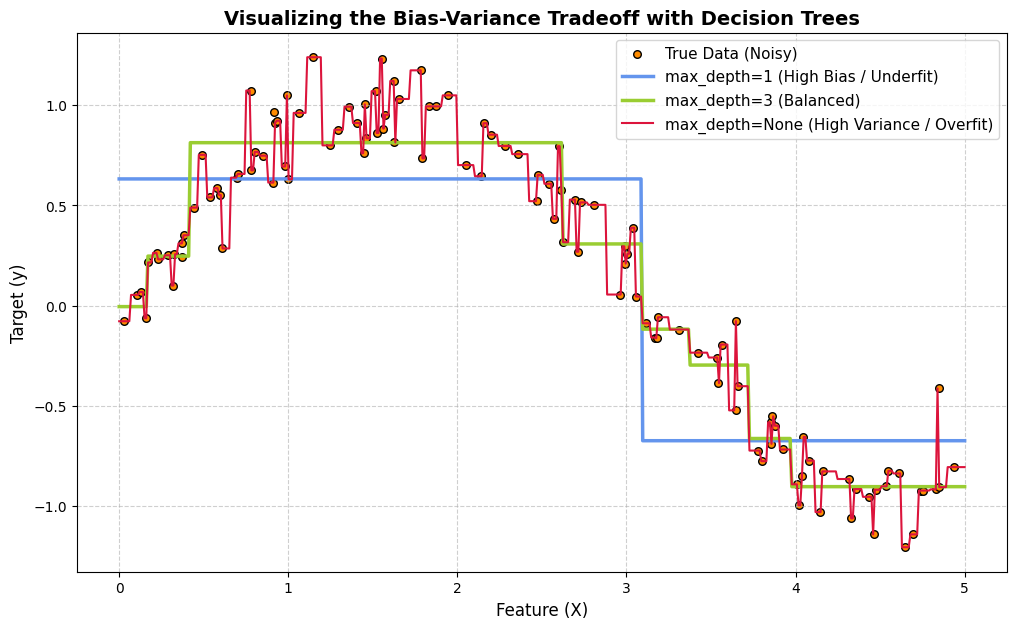

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# 1. Generate a non-linear regression dataset (Noisy Sine Wave)
np.random.seed(42)
X = np.sort(5 * np.random.rand(120, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.15, X.shape[0])

# Generate a dense grid of points for smooth plotting of prediction lines
X_test = np.linspace(0, 5, 500)[:, np.newaxis]

# 2. Train three DecisionTreeRegressor models with different max_depth values
# Underfitted: High Bias
model_underfit = DecisionTreeRegressor(max_depth=1)
model_underfit.fit(X, y)

# Balanced: Sweet Spot
model_balanced = DecisionTreeRegressor(max_depth=3)
model_balanced.fit(X, y)

# Overfitted: High Variance
model_overfit = DecisionTreeRegressor(max_depth=None)
model_overfit.fit(X, y)

# 3. Predict on the test grid
y_pred_underfit = model_underfit.predict(X_test)
y_pred_balanced = model_balanced.predict(X_test)
y_pred_overfit = model_overfit.predict(X_test)

# 4. Plot the results
plt.figure(figsize=(12, 7))

# Plot the training data points
plt.scatter(X, y, s=30, edgecolor="black", c="darkorange", label="True Data (Noisy)")

# Plot the prediction lines
plt.plot(X_test, y_pred_underfit, color="cornflowerblue", label="max_depth=1 (High Bias / Underfit)", linewidth=2.5)
plt.plot(X_test, y_pred_balanced, color="yellowgreen", label="max_depth=3 (Balanced)", linewidth=2.5)
plt.plot(X_test, y_pred_overfit, color="crimson", label="max_depth=None (High Variance / Overfit)", linewidth=1.5)

# Graph configuration
plt.xlabel("Feature (X)", fontsize=12)
plt.ylabel("Target (y)", fontsize=12)
plt.title("Visualizing the Bias-Variance Tradeoff with Decision Trees", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()